# 05 — Evaluación (Evaluation)

**Produce:** las tablas de evaluación en `reports/tables/` (`evaluacion_interna.csv`, `estabilidad.csv`, `contraste_externo.csv`), las figuras de diagnóstico en `reports/figures/` (`silueta_diagrama.png`, `estabilidad_ari.png`, `puntaje_por_grupo.png`) y, en `models/`, el resumen numérico de la fase (`clustering_evaluation.json`) más el PCA reconstruido (`clustering_pca.joblib`).

## 5.1 Qué se hace en esta fase

La fase 04 dejó un modelo ajustado y una etiqueta de grupo para cada uno de los 1310 lotes, pero no alcanzó a decir si se puede confiar en esos grupos. Eso es lo que se revisa acá, en cuatro frentes:

1. **Validación interna.** Recalcular las métricas de calidad del agrupamiento del modelo final, esta vez en los dos espacios que importan, y mirar el desglose lote por lote para ver si algún grupo quedó mal definido.
2. **Estabilidad.** Repetir el agrupamiento cambiando la semilla y quitando el 20 % de los lotes cada vez, para ver si los grupos se mantienen o si cambian de una corrida a otra.
3. **Contraste externo.** Cruzar los grupos con `Total.Cup.Points >= 80`, que no entró al clustering, para ver si el modelo reprodujo la convención de la industria o encontró algo distinto.
4. **Criterios de éxito.** Volver a la sección 1.5 de la fase 01 y revisar, criterio por criterio, qué se cumplió, qué se cumplió a medias y qué no.

## 5.2 Contexto: qué significa evaluar un clustering

Evaluar un modelo supervisado es relativamente cómodo, porque existe una respuesta correcta contra la cual comparar: se separa un conjunto de prueba, se predice y se cuenta cuántas veces se acertó. Acá no hay nada de eso. Nunca existió una columna que dijera a qué perfil pertenece cada lote, así que no hay una "precisión" que reportar ni un conjunto de prueba que tenga sentido apartar. Lo que se puede hacer es preguntarse tres cosas distintas, y ninguna de las tres reemplaza a las otras dos.

La primera es qué tan bien formados están los grupos por su propia geometría, es decir, si los lotes de un grupo se parecen entre sí más de lo que se parecen a los del grupo vecino. Eso lo miden las métricas internas que ya se usaron en la fase 04 (silueta, Davies-Bouldin y Calinski-Harabasz), y su límite es evidente: solo hablan de la forma de las nubes, no de si esas nubes significan algo.

La segunda es qué tan estable es el resultado. Un agrupamiento que cambia por completo cuando se corre con otra semilla, o cuando se le quita una quinta parte de los lotes, no describe la estructura de los datos sino la de una corrida en particular, y no se puede sustentar. Para comparar dos particiones se usa el **índice de Rand ajustado (ARI)**, que es la herramienta central de esta fase:

| Aspecto | Detalle |
|---|---|
| Rango | de −1 a 1 |
| 1 | las dos particiones coinciden perfectamente: los mismos lotes quedan juntos y los mismos lotes quedan separados |
| 0 | la coincidencia es la que se esperaría por puro azar |
| valores negativos | la coincidencia es peor que el azar, algo raro en la práctica |
| Por qué sirve acá | compara dos particiones sin importar cómo se numeraron los grupos, así que el "grupo 0" de una corrida se puede corresponder con el "grupo 2" de otra y el ARI sigue dando 1 |

La tercera es si los grupos tienen algún respaldo por fuera del propio modelo. Como `Total.Cup.Points` se dejó deliberadamente fuera del agrupamiento, se puede usar de referencia externa: si los grupos se ordenan según ese puntaje sin haberlo visto nunca, es señal de que capturaron algo real y no un artefacto del algoritmo.

Vale la pena dejar anotada una cautela sobre la silueta antes de recalcularla. La fase 04 comparó las tres representaciones (los 7 atributos, `pca_2` y `pca_4`) por su silueta y `pca_2` ganó de lejos, pero esa comparación no es del todo limpia: reducir dimensiones tiende a subir la silueta por construcción, porque el PCA se queda justamente con las direcciones donde los datos se estiran y descarta las que solo aportan dispersión. Una silueta calculada sobre 2 componentes no es entonces directamente comparable con una calculada sobre 7 atributos. Por eso acá se recalcula el modelo final en los dos espacios: en `pca_2`, que es donde se ajustó y donde vive la métrica que se reportó en la fase 04, y en los 7 atributos estandarizados, que es donde vive el significado sensorial de los grupos.

## 5.3 Carga de artefactos y verificación de reproducibilidad

Lo primero es volver a armar exactamente el modelo de la fase 04, porque todo lo que viene después se compara contra él. Se cargan la matriz de entrada de la fase 03, el dataset con la columna `grupo` que dejó la fase 04, el `.joblib` del k-means y el JSON de metadatos, y con eso se repite el ajuste desde cero para comprobar que se llega a las mismas etiquetas.

Acá apareció un hueco de la fase 04 que esta fase cierra. El modelo final se ajustó sobre las dos primeras componentes principales, pero lo único que se guardó en `models/` fue el k-means; el PCA se creó dentro del notebook 04 y se perdió al cerrarlo. Sin ese objeto no se puede llevar un lote nuevo del espacio de los 7 atributos al de 2 componentes, que es justamente lo que necesita el k-means guardado para asignarle un grupo, así que el modelo serializado quedaba, en la práctica, inservible para lotes nuevos. Por eso acá se reconstruye el PCA con los mismos parámetros y se guarda en `models/clustering_pca.joblib`.

In [1]:
import sys
sys.path.insert(0, "..")  # para poder importar src/ desde notebooks/

import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score)

from src.config import load_config, resolve_path
from src.models.train_model import silhouette_by_group  # ya existe de la fase 04, no se reescribe

%matplotlib inline
pd.set_option('display.max_columns', 30)
config = load_config()

# Todos los parámetros de la fase salen del config, ninguno se escribe suelto acá.
SEED = config['project']['random_seed']
FINAL = config['clustering']['final']                               # representacion / algoritmo / k
KMEANS_PARAMS = config['clustering']['algorithms']['kmeans']        # {'n_init': 10}
REFERENCE_COLUMN = config['validation']['reference_column']         # Total.Cup.Points
SPECIALTY_THRESHOLD = config['validation']['specialty_threshold']   # 80
ESTABILIDAD = config['validation']['stability']                     # n_seeds / n_subsamples / subsample_fraction

processed = resolve_path(config['paths']['data']['processed_dir'])
models_dir = resolve_path(config['paths']['models_dir'])
figures_dir = resolve_path(config['paths']['reports']['figures_dir'])
tables_dir = resolve_path(config['paths']['reports']['tables_dir'])

X = pd.read_csv(processed / 'clustering_input.csv')
coffee = pd.read_csv(processed / 'coffee_clustered.csv')
# El .joblib de la fase 04 dispara un aviso al cargarlo porque se guardó desde un
# entorno con otra versión de scikit-learn (ver el hallazgo de esta sección). Se captura
# en lugar de dejarlo pasar para imprimir solo su mensaje, que es donde están las dos
# versiones: el aviso completo trae además la ruta local del entorno, que no tiene por
# qué quedar guardada en el notebook.
with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter('always')
    modelo_guardado = joblib.load(models_dir / 'clustering_model.joblib')
metadata = json.loads((models_dir / 'clustering_metadata.json').read_text(encoding='utf-8'))

print('Matriz de entrada:', X.shape, '| dataset con grupo:', coffee.shape)
print('Modelo elegido en la fase 04:', FINAL['representation'], '+', FINAL['algorithm'],
      'con k =', FINAL['k'], '| semilla', SEED)
print('Modelo guardado en models/:', modelo_guardado)
print('Parámetros de estabilidad:', ESTABILIDAD)
for aviso in avisos:
    print('Aviso al cargar el modelo:',
          str(aviso.message).split(' Use at your own risk')[0])

Matriz de entrada: (1310, 7) | dataset con grupo: (1310, 24)
Modelo elegido en la fase 04: pca_2 + kmeans con k = 3 | semilla 42
Modelo guardado en models/: KMeans(n_clusters=3, n_init=10, random_state=42)
Parámetros de estabilidad: {'n_seeds': 20, 'n_subsamples': 50, 'subsample_fraction': 0.8}
Aviso al cargar el modelo: Trying to unpickle estimator KMeans from version 1.9.0 when using version 1.4.2. This might lead to breaking code or invalid results.


In [2]:
# El modelo de la fase 04 se ajustó sobre las 2 primeras componentes principales, pero
# ese PCA no se guardó: se reconstruye con los mismos parámetros para poder repetir el
# ajuste tal cual y, sobre todo, para poder proyectar lotes nuevos más adelante.
pca = PCA(n_components=2, random_state=SEED)
M_pca2 = pca.fit_transform(X)

kmeans = KMeans(n_clusters=FINAL['k'], random_state=SEED, **KMEANS_PARAMS).fit(M_pca2)
etiquetas = kmeans.labels_
etiquetas_guardadas = coffee['grupo'].to_numpy()

# ARI = 1.0 significa que las dos particiones son idénticas, aun si numeraran distinto los grupos.
print('ARI (reajuste vs. columna `grupo` de la fase 04):',
      round(adjusted_rand_score(etiquetas_guardadas, etiquetas), 4))
print('ARI (reajuste vs. etiquetas guardadas dentro del .joblib):',
      round(adjusted_rand_score(modelo_guardado.labels_, etiquetas), 4))
print('¿Coinciden lote a lote, con la misma numeración?:',
      bool((etiquetas == etiquetas_guardadas).all()))
print('Tamaño de los grupos reproducidos:', np.bincount(etiquetas).tolist(),
      '| tamaños de la fase 04:', metadata['tam_grupos'])
print('Varianza de los 7 atributos que retiene pca_2:',
      round(pca.explained_variance_ratio_.sum() * 100, 1), '%')

# Se guarda el PCA reconstruido: sin él el k-means guardado no sirve para lotes nuevos.
joblib.dump(pca, models_dir / 'clustering_pca.joblib')
print('Guardado en models/:', 'clustering_pca.joblib')

ARI (reajuste vs. columna `grupo` de la fase 04): 1.0
ARI (reajuste vs. etiquetas guardadas dentro del .joblib): 1.0
¿Coinciden lote a lote, con la misma numeración?: True
Tamaño de los grupos reproducidos: [708, 295, 307] | tamaños de la fase 04: {'0': 708, '1': 295, '2': 307}
Varianza de los 7 atributos que retiene pca_2: 79.3 %
Guardado en models/: clustering_pca.joblib


**Hallazgo.** El reajuste reprodujo el modelo de la fase 04 sin ninguna diferencia: el ARI contra la columna `grupo` guardada es **1.0**, y de hecho las etiquetas coinciden lote a lote con la misma numeración, así que los grupos 0, 1 y 2 de esta fase son los mismos 0, 1 y 2 de la fase 04 y todo lo que se diga de aquí en adelante se puede leer contra las tablas de ese notebook. Los tamaños también cuadran con los metadatos: **708**, **295** y **307** lotes. Las dos primeras componentes retienen el **79.3 %** de la varianza de los 7 atributos.

Al cargar el `.joblib` aparece un aviso de scikit-learn que vale la pena dejar anotado: el archivo se guardó desde un entorno con la versión 1.9.0 y acá se está leyendo con la 1.4.2, que es la que fija `requirements.txt`. El modelo se cargó bien y sus etiquetas internas también dan ARI 1.0 contra el reajuste, así que no hubo consecuencias, pero es un recordatorio de por qué esta sección reajusta el modelo en lugar de confiar en el objeto serializado, y de que a alguna de las dos partes (el entorno de quien corrió la fase 04 o el `requirements.txt`) le falta un ajuste.

## 5.4 Validación interna

Ahora sí las métricas del modelo final. Se calculan las tres de `config -> validation.internal_metrics` en los dos espacios que se discutieron en 5.2: en `pca_2`, que es donde el k-means ajustó y separó, y en los 7 atributos estandarizados, que es el espacio donde cada dimensión sigue siendo un atributo de catación con significado propio. Las etiquetas son las mismas en los dos casos; lo único que cambia es en qué espacio se miden las distancias.

In [3]:
M_7atributos = X.to_numpy()
espacios = {
    'pca_2 (donde se ajustó)': M_pca2,
    '7 atributos estandarizados': M_7atributos,
}

filas = []
for nombre, M in espacios.items():
    filas.append({
        'espacio': nombre,
        'silhouette': round(silhouette_score(M, etiquetas), 4),
        'davies_bouldin': round(davies_bouldin_score(M, etiquetas), 4),
        'calinski_harabasz': round(calinski_harabasz_score(M, etiquetas), 1),
    })
metricas_internas = pd.DataFrame(filas)
print(metricas_internas.to_string(index=False))

print('\nPara comparar, lo que reportó la fase 04 (models/clustering_metadata.json):')
print('  silhouette', metadata['silhouette'],
      '| davies_bouldin', metadata['davies_bouldin'],
      '| calinski_harabasz', metadata['calinski_harabasz'])

                   espacio  silhouette  davies_bouldin  calinski_harabasz
   pca_2 (donde se ajustó)      0.4279          0.7608             1505.9
7 atributos estandarizados      0.2955          1.0878              812.0

Para comparar, lo que reportó la fase 04 (models/clustering_metadata.json):
  silhouette 0.4279 | davies_bouldin 0.7608 | calinski_harabasz 1505.9


In [4]:
# Desglose de la silueta lote por lote, agrupado por grupo. Se calcula en pca_2, el
# espacio donde el modelo separó, para que el número sea comparable con el de la fase 04.
silueta_grupos = silhouette_by_group(M_pca2, etiquetas)
print(silueta_grupos)

       media  minimo    p25  pct_negativa    n
grupo                                         
0      0.452   0.011  0.330           0.0  708
1      0.422  -0.016  0.315           1.0  295
2      0.379  -0.016  0.274           1.6  307


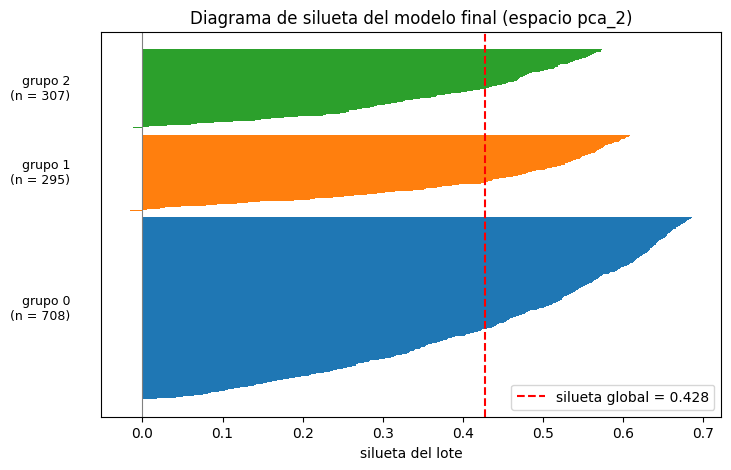

In [5]:
sil_lotes = silhouette_samples(M_pca2, etiquetas)
silueta_global = silhouette_score(M_pca2, etiquetas)

# Diagrama de silueta: una barra horizontal por lote, ordenadas de menor a mayor
# dentro de cada grupo. Los grupos se separan con un espacio en blanco.
fig, ax = plt.subplots(figsize=(8, 5))
y = 0
for g in sorted(set(etiquetas)):
    valores = np.sort(sil_lotes[etiquetas == g])
    ax.barh(range(y, y + len(valores)), valores, height=1, color=plt.cm.tab10(g))
    ax.text(-0.09, y + len(valores) / 2, f'grupo {g}\n(n = {len(valores)})',
            va='center', ha='right', fontsize=9)
    y += len(valores) + 25
ax.axvline(0, color='gray', lw=.8)
ax.axvline(silueta_global, color='red', ls='--',
           label=f'silueta global = {silueta_global:.3f}')
ax.set_xlabel('silueta del lote'); ax.set_yticks([]); ax.legend(loc='lower right')
ax.set_title('Diagrama de silueta del modelo final (espacio pca_2)')
fig.savefig(figures_dir / 'silueta_diagrama.png', bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** En `pca_2`, el espacio donde el modelo se ajustó, la silueta dio **0.4279**, exactamente el valor que había reportado la fase 04. En los 7 atributos estandarizados la misma partición baja a **0.2955**, y las otras dos métricas se mueven en la misma dirección: Davies-Bouldin sube de 0.761 a 1.088 (más alto es peor) y Calinski-Harabasz cae de 1506 a 812 (más alto es mejor). Es decir, los tres indicadores coinciden en que los grupos se ven bastante mejor separados en el plano de las dos componentes que en el espacio sensorial completo, y la diferencia no es menor: la silueta se cae casi a la mitad.

Esto era esperable y confirma la cautela de 5.2. El PCA se queda con las dos direcciones donde los lotes más se estiran y descarta las otras cinco, que en el espacio original meten dispersión dentro de cada grupo sin ayudar a separarlos. Lo importante es la lectura práctica: la silueta honesta del modelo, si lo que se quiere describir son perfiles sensoriales, está más cerca de **0.30** que de **0.43**, y ese es un nivel de separación moderado tirando a débil. Los grupos existen y ordenan a los lotes, pero no son nubes aisladas.

El desglose por grupo agrega el detalle de que ningún grupo quedó roto. Las siluetas promedio por grupo son **0.452** (grupo 0), **0.422** (grupo 1) y **0.379** (grupo 2), y el porcentaje de lotes con silueta negativa, que es la señal de que un lote encajaría mejor en otro grupo, es de **0 %**, **1 %** y **1.6 %**, menos de diez lotes en total sobre 1310. En el diagrama se ve por qué: los tres bloques tienen una forma parecida, con una cola que baja hacia cero en el borde de cada grupo, que es donde se toca con el grupo vecino. El grupo 2, el de calidad más alta, es el que queda un poco menos definido, algo que ya había anotado la fase 04 y que conviene recordar cuando se lo describa en la fase 06.

## 5.5 Estabilidad frente a la semilla

K-means arranca poniendo sus centros en posiciones aleatorias y los va moviendo hasta que se estabilizan, así que dos corridas con semillas distintas pueden terminar en soluciones distintas. La configuración del proyecto usa `n_init: 10`, que ya repite ese arranque diez veces y se queda con el mejor, pero eso no garantiza que la semilla no importe. Lo que se hace acá es reajustar el k-means sobre la misma matriz `pca_2`, con las semillas 0 a 19 (`validation.stability.n_seeds`), y medir con el ARI cuánto se parece cada corrida a la partición del modelo final, que usa la semilla 42.

In [6]:
filas = []
for semilla in range(ESTABILIDAD['n_seeds']):
    etiquetas_semilla = KMeans(n_clusters=FINAL['k'], random_state=semilla,
                               **KMEANS_PARAMS).fit_predict(M_pca2)
    filas.append({'semilla': semilla,
                  'ari': round(adjusted_rand_score(etiquetas, etiquetas_semilla), 4)})
estabilidad_semillas = pd.DataFrame(filas)

print('ARI contra el modelo final, sobre', ESTABILIDAD['n_seeds'], 'semillas distintas:')
print(estabilidad_semillas['ari'].agg(['mean', 'min', 'max']).round(4).to_string())
print('\nCorridas con ARI = 1.0 (partición idéntica):',
      int((estabilidad_semillas['ari'] == 1.0).sum()), 'de', len(estabilidad_semillas))
print('\nLas 5 corridas que más se alejaron:')
print(estabilidad_semillas.sort_values('ari').head(5).to_string(index=False))

ARI contra el modelo final, sobre 20 semillas distintas:
mean    0.9961
min     0.9877
max     1.0000

Corridas con ARI = 1.0 (partición idéntica): 13 de 20

Las 5 corridas que más se alejaron:
 semilla    ari
       2 0.9877
      14 0.9877
      18 0.9877
      11 0.9877
       1 0.9902


**Hallazgo.** La semilla prácticamente no cambia nada: el ARI promedio contra el modelo final fue de **0.996**, con un mínimo de **0.988** y un máximo de **1.0**, y **13 de las 20** corridas dieron una partición literalmente idéntica. Las siete que se desviaron lo hicieron por unos pocos lotes de frontera que cambiaron de tramo, no por una reorganización de los grupos. Con `n_init: 10` esto era lo esperable, y deja claro que la partición no depende del arranque aleatorio.

## 5.6 Estabilidad frente a submuestras

La prueba de la semilla es la fácil. La que de verdad importa es si los grupos sobreviven a cambiar los datos, porque un agrupamiento que se rearma cuando se le quita una parte de los lotes está describiendo esa muestra puntual y no la estructura del fenómeno. Lo que se hizo fue tomar 50 submuestras aleatorias del 80 % de los lotes (`validation.stability.n_subsamples` y `subsample_fraction`) y, en cada una, repetir el procedimiento completo desde cero: reajustar el PCA y reajustar el k-means solo con esos lotes. Reajustar también el PCA es importante, porque si se dejara fijo el de la muestra completa la prueba no diría nada sobre lo sensible que es la reducción de dimensiones a los datos, que es la mitad del modelo.

Después se compara con el ARI la partición de cada submuestra contra las etiquetas del modelo final restringidas a esos mismos lotes, nunca contra los 1310, porque los lotes que quedaron fuera no tienen etiqueta nueva con la cual compararse.

In [7]:
n_lotes = len(X)
tamano_submuestra = int(ESTABILIDAD['subsample_fraction'] * n_lotes)
generador = np.random.default_rng(SEED)   # el submuestreo también sale de la semilla del config

filas = []
indices_submuestras = []    # qué lotes entraron en cada submuestra (se reutiliza en 5.7)
etiquetas_submuestras = []  # qué grupo les asignó el reajuste de esa submuestra

for iteracion in range(ESTABILIDAD['n_subsamples']):
    indices = generador.choice(n_lotes, size=tamano_submuestra, replace=False)
    X_sub = X.iloc[indices]

    # Se repite el procedimiento completo, PCA incluido: dejar el PCA fijo escondería
    # la mitad de la variabilidad que se quiere medir.
    M_sub = PCA(n_components=2, random_state=SEED).fit_transform(X_sub)
    etiquetas_sub = KMeans(n_clusters=FINAL['k'], random_state=SEED,
                           **KMEANS_PARAMS).fit_predict(M_sub)

    # Se compara contra las etiquetas del modelo final SOLO en los lotes de esta submuestra.
    filas.append({'iteracion': iteracion,
                  'ari': round(adjusted_rand_score(etiquetas[indices], etiquetas_sub), 4)})
    indices_submuestras.append(indices)
    etiquetas_submuestras.append(etiquetas_sub)

estabilidad_submuestras = pd.DataFrame(filas)
print('Submuestras:', ESTABILIDAD['n_subsamples'], 'de', tamano_submuestra, 'lotes cada una',
      f"({ESTABILIDAD['subsample_fraction'] * 100:.0f} % de {n_lotes})")
print('\nARI contra el modelo final:')
print(estabilidad_submuestras['ari'].agg(['mean', 'std', 'min', 'max']).round(4).to_string())
print('\nSubmuestras con ARI >= 0.9:', int((estabilidad_submuestras['ari'] >= 0.9).sum()),
      'de', len(estabilidad_submuestras))

Submuestras: 50 de 1048 lotes cada una (80 % de 1310)

ARI contra el modelo final:
mean    0.9517
std     0.0580
min     0.7770
max     0.9969

Submuestras con ARI >= 0.9: 44 de 50


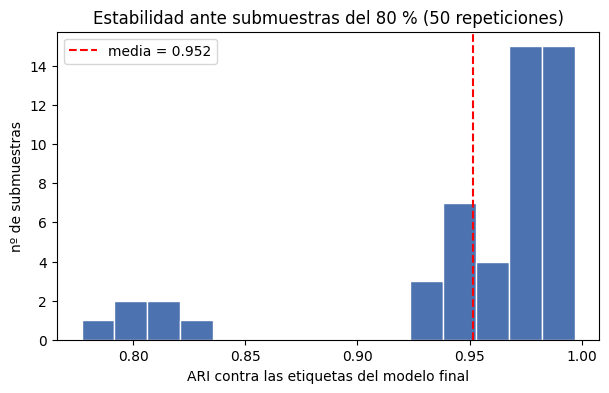

In [8]:
media_ari = estabilidad_submuestras['ari'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(estabilidad_submuestras['ari'], bins=15, color='#4c72b0', edgecolor='white')
ax.axvline(media_ari, color='red', ls='--', label=f'media = {media_ari:.3f}')
ax.set_xlabel('ARI contra las etiquetas del modelo final')
ax.set_ylabel('nº de submuestras')
ax.set_title(f"Estabilidad ante submuestras del "
             f"{ESTABILIDAD['subsample_fraction'] * 100:.0f} % "
             f"({ESTABILIDAD['n_subsamples']} repeticiones)")
ax.legend()
fig.savefig(figures_dir / 'estabilidad_ari.png', bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** Quitar un 20 % de los lotes tampoco desarma los grupos: el ARI promedio de las 50 submuestras fue **0.952**, con una desviación de **0.058**, y **44 de las 50** quedaron por encima de 0.9. El histograma muestra la mayoría de las corridas amontonadas entre 0.95 y 1.0, y aparte un grupito de **6 corridas** que se quedaron entre 0.78 y 0.83: el peor caso dio **0.777**, que sigue siendo una coincidencia alta, y el mejor **0.997**.

La cola de la izquierda tiene una explicación que conviene mencionar porque es propia de este dataset. Como los grupos son tres tramos de un mismo eje de calidad y no nubes separadas, las fronteras entre tramos las decide el algoritmo según dónde caigan los lotes que le tocaron; cuando una submuestra deja por fuera lotes de una zona de frontera, esa frontera se corre un poco y varias decenas de lotes cambian de tramo de golpe. No es que aparezcan grupos distintos, es que el corte se mueve. La media de 0.95 dice que ese corrimiento es pequeño en la mayoría de las corridas.

## 5.7 Estabilidad de la asignación lote a lote

El ARI es un número por corrida, y eso deja una pregunta sin responder: qué le pasa a cada lote en particular. Un ARI de 0.95 no dice si el 5 % que no coincide son siempre los mismos lotes de frontera o si cualquiera puede cambiar de grupo. Para saberlo hay que contar, lote por lote, cuántas veces conservó el grupo que le asignó el modelo final.

Y acá aparece el problema que hace que esta sección sea la más delicada del notebook. Los algoritmos de clustering numeran los grupos de forma completamente arbitraria: dependiendo del arranque aleatorio, el tramo de calidad alta puede salir como "grupo 2" en una corrida y como "grupo 0" en la siguiente, sin que la partición haya cambiado en absoluto. Comparar las etiquetas de frente, número contra número, mediría el orden en que el algoritmo bautizó los grupos y no si los lotes se mantuvieron juntos. Por eso antes de contar hay que emparejar los grupos de cada corrida con los del modelo final, y la regla que se usa es la más simple que hay: cada grupo nuevo se empareja con el grupo original con el que más lotes comparte. El código de abajo va comentado línea por línea porque es el único paso del notebook que no se explica solo.

In [9]:
# Contadores por lote: cuántas veces entró a una submuestra, y en cuántas de esas
# veces conservó el grupo que le había asignado el modelo final.
veces_incluido = np.zeros(n_lotes)
veces_conservado = np.zeros(n_lotes)
porcentaje_por_corrida = []
corridas_ambiguas = 0

# Se recorren las submuestras que ya se ajustaron en 5.6, no se vuelven a ajustar.
for indices, etiquetas_sub in zip(indices_submuestras, etiquetas_submuestras):

    # Etiquetas del modelo final, restringidas a los lotes de esta submuestra.
    etiquetas_originales = etiquetas[indices]

    # Tabla de contingencia entre las dos numeraciones: las filas son los grupos de
    # esta corrida y las columnas los grupos del modelo final. Cada celda cuenta
    # cuántos lotes de la submuestra tienen ese par de etiquetas.
    tabla = pd.crosstab(etiquetas_sub, etiquetas_originales)

    # Emparejamiento. Para cada grupo nuevo (cada fila), idxmax(axis=1) devuelve la
    # columna con el conteo más alto, es decir, el grupo original con el que comparte
    # más lotes. Ese es su equivalente. Sin este paso la comparación mediría la
    # numeración arbitraria del algoritmo y no la coincidencia real de los grupos.
    equivalencia = tabla.idxmax(axis=1)

    # Si dos grupos nuevos apuntaran al mismo grupo original, el emparejamiento
    # quedaría ambiguo (un grupo original sin pareja). Se cuenta para saber si pasó.
    if equivalencia.nunique() < len(equivalencia):
        corridas_ambiguas += 1

    # Se traducen las etiquetas de esta corrida a la numeración del modelo final,
    # reemplazando cada grupo nuevo por su equivalente.
    etiquetas_traducidas = pd.Series(etiquetas_sub).map(equivalencia).to_numpy()

    # Ya con las dos numeraciones alineadas, la comparación lote a lote tiene sentido.
    coincide = etiquetas_traducidas == etiquetas_originales
    porcentaje_por_corrida.append(coincide.mean() * 100)

    # Se acumula por lote para poder desglosar el resultado por grupo más abajo.
    veces_incluido[indices] += 1
    veces_conservado[indices] += coincide

print('% de lotes que conservan su grupo, promedio entre submuestras:',
      round(float(np.mean(porcentaje_por_corrida)), 2))
print('  peor corrida:', round(float(np.min(porcentaje_por_corrida)), 2),
      '% | mejor corrida:', round(float(np.max(porcentaje_por_corrida)), 2), '%')
print('Corridas con emparejamiento ambiguo:', corridas_ambiguas, 'de',
      len(porcentaje_por_corrida))
print('Lotes que nunca entraron a ninguna submuestra:', int((veces_incluido == 0).sum()),
      '| veces que entró un lote, en promedio:', round(float(veces_incluido.mean()), 1))

% de lotes que conservan su grupo, promedio entre submuestras: 98.44
  peor corrida: 92.56 % | mejor corrida: 99.9 %
Corridas con emparejamiento ambiguo: 0 de 50
Lotes que nunca entraron a ninguna submuestra: 0 | veces que entró un lote, en promedio: 40.0


In [10]:
# Porcentaje de veces que cada lote conservó su grupo, desglosado por el grupo que le
# asignó el modelo final.
porcentaje_por_lote = veces_conservado / veces_incluido * 100

estabilidad_por_grupo = (
    pd.DataFrame({'grupo': etiquetas, 'pct_conserva': porcentaje_por_lote})
    .groupby('grupo')['pct_conserva']
    .agg(media='mean', minimo='min', p25=lambda s: s.quantile(0.25), n='count')
    .round(2)
)
print(estabilidad_por_grupo)

# ¿Cuántos lotes son realmente inestables?
print('\nLotes que conservaron su grupo en menos del 80 % de las veces:',
      int((porcentaje_por_lote < 80).sum()), 'de', n_lotes)

       media  minimo    p25    n
grupo                           
0      98.70   47.62  100.0  708
1      98.09   62.16  100.0  295
2      98.26   55.00  100.0  307

Lotes que conservaron su grupo en menos del 80 % de las veces: 32 de 1310


**Hallazgo.** El emparejamiento funcionó sin ambigüedades en las 50 corridas (nunca dos grupos nuevos reclamaron el mismo grupo original), y el resultado es que en promedio el **98.44 %** de los lotes de cada submuestra conservó su grupo, con la peor corrida en **92.56 %** y la mejor en **99.9 %**. Desglosado por grupo, la cifra es casi la misma en los tres: **98.7 %** en el grupo 0, **98.09 %** en el grupo 1 y **98.26 %** en el grupo 2, así que no hay un grupo que sea el frágil.

Lo que sí muestra el desglose es que la inestabilidad está concentrada en unos pocos lotes y no repartida. Los mínimos por grupo bajan hasta **47.62 %**, **62.16 %** y **55 %**, es decir, hay lotes que cambiaron de grupo casi la mitad de las veces que entraron a una submuestra. Son los lotes que caen justo en las fronteras entre tramos, los mismos que ya salían con silueta cercana a cero en el diagrama de 5.4. Con esto los dos diagnósticos apuntan al mismo sitio: la partición como tal es sólida, y la duda está en un puñado de lotes de borde, que es exactamente lo que se espera cuando los grupos son tramos de un continuo.

## 5.8 Contraste externo contra la convención de la industria

Hasta acá todo lo que se midió es interno: métricas que miran la forma de los grupos y pruebas que comparan el modelo consigo mismo. Nada de eso dice si los grupos significan algo. Para eso hace falta una referencia que el modelo no haya visto, y en este proyecto existe una a la mano: `Total.Cup.Points` se dejó deliberadamente fuera del clustering desde la fase 03, porque es la suma de los subpuntajes y habría entrado dos veces. La convención de la industria pone en **80 puntos** el corte del café de especialidad (`validation.reference_column` y `validation.specialty_threshold`), así que se puede armar una partición binaria con ese umbral y contrastarla contra los tres grupos.

Conviene tener claro qué se espera y qué no. Si los grupos coincidieran perfectamente con el corte de 80 puntos, el clustering no habría aportado nada nuevo, solo habría redescubierto una regla que ya estaba escrita. Si no tuvieran ninguna relación, habría que sospechar que agruparon ruido. Lo interesante es el punto intermedio: que los grupos se ordenen según el puntaje, porque eso confirma que capturaron calidad, pero que no lo reproduzcan, porque eso es lo que justifica haberlos buscado.

In [11]:
# La partición binaria de la industria: especialidad sí / no, según el umbral del config.
especialidad = coffee[REFERENCE_COLUMN] >= SPECIALTY_THRESHOLD

# Tabla cruzada grupo x especialidad, con los conteos y el porcentaje por fila.
tabla_cruzada = pd.crosstab(coffee['grupo'], especialidad)
tabla_cruzada.columns = [f'< {SPECIALTY_THRESHOLD}', f'>= {SPECIALTY_THRESHOLD}']
porcentajes_fila = (tabla_cruzada.div(tabla_cruzada.sum(axis=1), axis=0) * 100).round(1)

contraste_externo = pd.concat([tabla_cruzada, porcentajes_fila.add_suffix(' (%)')], axis=1)
contraste_externo['n'] = tabla_cruzada.sum(axis=1)
print(contraste_externo)

# Porcentaje global de lotes que ya son de especialidad, sobre los 1310 lotes de trabajo.
pct_global_especialidad = especialidad.mean() * 100
print(f'\nLotes con {REFERENCE_COLUMN} >= {SPECIALTY_THRESHOLD}: '
      f'{int(especialidad.sum())} de {len(coffee)} ({pct_global_especialidad:.1f} %)')

       < 80  >= 80  < 80 (%)  >= 80 (%)    n
grupo                                       
0        24    684       3.4       96.6  708
1       154    141      52.2       47.8  295
2         2    305       0.7       99.3  307

Lotes con Total.Cup.Points >= 80: 1130 de 1310 (86.3 %)


In [12]:
# ARI entre la partición de 3 grupos y la binaria de 80 puntos.
ari_grupos_umbral = adjusted_rand_score(coffee['grupo'], especialidad.astype(int))
print('ARI entre los 3 grupos y la partición binaria de 80 puntos:',
      round(ari_grupos_umbral, 4))

# Estadísticas del puntaje total por grupo (recordar: no entró al clustering).
resumen_puntaje = (coffee.groupby('grupo')[REFERENCE_COLUMN]
                   .agg(n='count', media='mean', desviacion='std',
                        minimo='min', maximo='max')
                   .round(2))
resumen_puntaje['pct_especialidad'] = (especialidad.groupby(coffee['grupo']).mean() * 100).round(1)
print()
print(resumen_puntaje)

ARI entre los 3 grupos y la partición binaria de 80 puntos: 0.1771

         n  media  desviacion  minimo  maximo  pct_especialidad
grupo                                                          
0      708  82.41        1.11   72.83   84.00              96.6
1      295  78.89        2.94   59.83   81.25              47.8
2      307  84.80        1.49   78.33   90.58              99.3


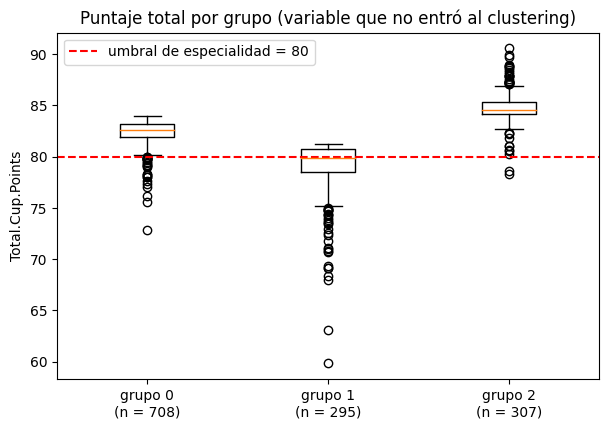

In [13]:
grupos_ordenados = sorted(coffee['grupo'].unique())
datos_por_grupo = [coffee.loc[coffee['grupo'] == g, REFERENCE_COLUMN] for g in grupos_ordenados]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot(datos_por_grupo, labels=[f'grupo {g}\n(n = {len(d)})'
                                    for g, d in zip(grupos_ordenados, datos_por_grupo)])
ax.axhline(SPECIALTY_THRESHOLD, color='red', ls='--',
           label=f'umbral de especialidad = {SPECIALTY_THRESHOLD}')
ax.set_ylabel(REFERENCE_COLUMN)
ax.set_title('Puntaje total por grupo (variable que no entró al clustering)')
ax.legend()
fig.savefig(figures_dir / 'puntaje_por_grupo.png', bbox_inches='tight', dpi=150)
plt.show()

**Hallazgo.** Los grupos quedaron ordenados por puntaje sin que el modelo lo haya visto nunca: el grupo 1 promedia **78.89** puntos, el grupo 0 **82.41** y el grupo 2 **84.80**, y el porcentaje de lotes de especialidad sigue el mismo orden, **47.8 %**, **96.6 %** y **99.3 %**. Eso es el respaldo externo que se buscaba: los siete atributos de catación, agrupados por su cuenta, reconstruyeron el eje de calidad que la industria resume en un solo número.

Pero no lo reprodujeron. El ARI entre los tres grupos y la partición binaria de 80 puntos es de apenas **0.177**, muy lejos de 1, y la tabla cruzada explica por qué: la línea de los 80 puntos parte al grupo 1 casi por la mitad (154 lotes por debajo y 141 por encima) mientras deja a los grupos 0 y 2 enteros del lado de la especialidad. Dicho de otra forma, el corte de la industria cae en medio de uno de los grupos, no entre los grupos. Los 180 lotes que no llegan a 80 puntos están casi todos en el grupo 1, pero el grupo 1 tiene 295 lotes, así que no es "el grupo de los que no son especialidad". La distinción entre los grupos 0 y 2, que juntos reúnen el **77 %** de los lotes de la base, es invisible para el umbral: los dos son de especialidad y ya, mientras que el clustering sí separa el café de 82 puntos del de 85. Ese es justamente el aporte del modelo.

El boxplot deja ver algo más que vale la pena anotar para la fase 06: los rangos se solapan. El grupo 0 llega hasta 84 puntos y el grupo 2 arranca en 78.33, así que hay lotes del grupo 2 con menos puntaje total que lotes del grupo 0. No es una contradicción, es la consecuencia de que los grupos se formaron con los siete atributos por separado y no con su suma: dos lotes pueden sumar lo mismo repartiendo distinto entre aroma, cuerpo y balance, y ahí es donde el agrupamiento ve una diferencia que el puntaje total borra.

**Sobre el porcentaje global.** El número real, calculado sobre los 1310 lotes de trabajo, es **86.3 %** (1130 lotes de especialidad). Esto destapó una inconsistencia en la documentación del proyecto: el README decía 86 %, que está bien, pero el texto de la sección 2.6 del notebook 02 afirmaba que "cerca del 90 % de los lotes supera el umbral de 80 puntos". Lo llamativo es que la propia celda de ese notebook imprime `86.3 %`, así que el error estaba solo en la redacción del hallazgo y no en el cálculo. Se corrigió el texto del notebook 02 con el número exacto.

## 5.9 Por qué k = 3 y no k = 2

La fase 04 dejó un argumento a medio cerrar. La silueta era más alta con `k=2` (0.458) que con `k=3` (0.428), y la decisión de quedarse con tres grupos se justificó diciendo que `k=2` "solo parte el eje de calidad en mejor y peor, que no aporta frente a lo que ya dice `Total.Cup.Points >= 80`". Es un argumento razonable, pero en ese momento era una intuición: nadie había medido si la partición de `k=2` se parece o no al corte de 80 puntos. Ahora que hay una referencia externa y una forma de comparar particiones, se puede verificar. Lo que se hace es reajustar el k-means con `k=2` sobre la misma matriz `pca_2` y calcular el ARI de esa partición contra la binaria de 80 puntos, para ponerlo al lado del ARI que ya se calculó para `k=3`.

In [14]:
# k = 2 es el extremo inferior del rango que barrió la fase 04 (config -> clustering.k_min).
K_ALTERNATIVO = config['clustering']['k_min']

etiquetas_k2 = KMeans(n_clusters=K_ALTERNATIVO, random_state=SEED,
                      **KMEANS_PARAMS).fit_predict(M_pca2)
ari_k2_umbral = adjusted_rand_score(etiquetas_k2, especialidad.astype(int))

print(f'ARI contra la binaria de {SPECIALTY_THRESHOLD} puntos:')
print(f'  k = {K_ALTERNATIVO}: {ari_k2_umbral:.4f}')
print(f"  k = {FINAL['k']}: {ari_grupos_umbral:.4f}")
print(f'\nSilueta en pca_2 con k = {K_ALTERNATIVO}:',
      round(silhouette_score(M_pca2, etiquetas_k2), 4),
      f"| con k = {FINAL['k']}:", round(silueta_global, 4))
print(f'\nTamaño de los grupos con k = {K_ALTERNATIVO}:', np.bincount(etiquetas_k2).tolist())
print(f'Tamaño de la partición binaria de {SPECIALTY_THRESHOLD} puntos:',
      [int((~especialidad).sum()), int(especialidad.sum())])
print(f'\nTabla cruzada de k = {K_ALTERNATIVO} contra el umbral:')
print(pd.crosstab(etiquetas_k2, especialidad))

ARI contra la binaria de 80 puntos:
  k = 2: 0.1551
  k = 3: 0.1771

Silueta en pca_2 con k = 2: 0.4581 | con k = 3: 0.4279

Tamaño de los grupos con k = 2: [768, 542]
Tamaño de la partición binaria de 80 puntos: [180, 1130]

Tabla cruzada de k = 2 contra el umbral:
Total.Cup.Points  False  True 
row_0                         
0                    12    756
1                   168    374


**Hallazgo.** Los números no confirman lo que había dicho la fase 04, y conviene decirlo tal cual. El ARI de `k=2` contra la binaria de 80 puntos es **0.155**, más bajo que el de `k=3`, que es **0.177**. Es decir, `k=2` no se parece más al corte de la industria: se parece un poco menos. La razón se ve en los tamaños. La partición de `k=2` reparte los lotes en **768** y **542**, o sea que corta el eje de calidad más o menos por la mitad, mientras el umbral de 80 puntos deja **180** lotes de un lado y **1130** del otro. Son dos cortes en alturas muy distintas del mismo eje, así que difícilmente van a coincidir.

Con esto, el argumento de la fase 04 hay que reformularlo. No es cierto que `k=2` reproduzca la escala que ya existe: ninguna de las dos particiones lo hace, y de hecho los dos ARI son bajos, lo que refuerza la conclusión de 5.8 de que el clustering no redescubrió la convención de la industria. Lo que sí se sostiene es la parte de fondo de la decisión, por otra vía. Con `k=2` los lotes se reparten en dos mitades de tamaño parecido y ninguna de las dos aísla a los 180 lotes que no llegan a 80 puntos, que son los que de verdad se diferencian del resto; con `k=3` aparece el grupo 1, que concentra **154 de esos 180 lotes** en un grupo de 295, y quedan además dos tramos distinguibles por encima del umbral, que es la información que el puntaje total no da. La ganancia de silueta de `k=2` (0.458 frente a 0.428) sigue siendo real, pero compra compacidad a cambio de una partición que no aporta nada que no se supiera.

## 5.10 Revisión de los criterios de éxito de la fase 01

La sección 1.5 de la fase 01 dejó dos criterios de éxito, uno de negocio y uno de minería de datos, cada uno con varias exigencias dentro. Acá se toman por partes y se contrasta cada una con lo que salió de esta evaluación. Algunas no se pueden resolver todavía porque dependen de la fase 06, y en esos casos lo honesto es dejarlas marcadas como pendientes en lugar de darlas por buenas.

| Criterio (fase 01, sección 1.5) | Cómo se midió | Resultado | Estado |
|---|---|---|---|
| "Los grupos obtenidos deben ser claramente diferenciables entre sí" | Silueta, Davies-Bouldin y Calinski-Harabasz del modelo final, en `pca_2` y en los 7 atributos estandarizados (5.4) | Silueta de **0.4279** en `pca_2` y de **0.2955** en el espacio sensorial completo; Davies-Bouldin 0.761 y 1.088; Calinski-Harabasz 1506 y 812 | **Se cumple parcialmente.** Una silueta de 0.43 es separación moderada, no excelente, y en el espacio donde los grupos tienen que interpretarse baja a 0.30. Los grupos se distinguen y se ordenan, pero son tramos de un continuo, no nubes aisladas |
| "evaluados con medidas de calidad de agrupamiento, como el coeficiente de silueta" | Las tres métricas de `validation.internal_metrics`, más el desglose de silueta por grupo y el diagrama lote por lote (5.4) | Siluetas por grupo de **0.452**, **0.422** y **0.379**, con menos de 10 lotes de silueta negativa en 1310 | **Se cumple.** Ningún grupo quedó mal definido y el diagnóstico está documentado con la métrica que la fase 01 había fijado como principal |
| "fáciles de interpretar" | Contraste externo contra `Total.Cup.Points` y estadísticas del puntaje por grupo (5.8) | Los tres grupos se ordenan por puntaje sin haberlo visto: **78.89**, **82.41** y **84.80** puntos de promedio | **Se cumple.** La lectura de los grupos es directa, son tres niveles de calidad de la taza |
| Implícito en "grupos claramente definidos y justificados" (objetivo de minería, 1.4) | Estabilidad ante 20 semillas y 50 submuestras del 80 %, y conservación de la asignación lote a lote (5.5 a 5.7) | ARI medio de **0.996** entre semillas y de **0.952** entre submuestras; el **98.44 %** de los lotes conserva su grupo | **Se cumple.** La partición no depende del arranque aleatorio ni de la muestra puntual; la variabilidad se concentra en unos 32 lotes de frontera |
| "las características que distinguen a cada grupo deben ser consistentes con lo que se observe en la exploración de los datos" | Comparación de los grupos con los hallazgos de la fase 02 sobre `Total.Cup.Points` (5.8) | El ordenamiento por puntaje y el sesgo de la base (**86.3 %** de lotes de especialidad) coinciden con lo descrito en la fase 02 | **Se cumple parcialmente.** Es consistente en lo sensorial, pero la consistencia por país, altitud, variedad y procesamiento es justamente lo que falta perfilar en la fase 06 |
| "señalar, con respaldo cuantitativo, qué condiciones de origen y manejo se asocian con los grupos de mejor calidad" | No evaluable en esta fase | Pendiente | **No se cumple todavía.** Es la tarea central de la fase 06; esta fase solo deja validado el insumo, que son los grupos |
| "el dashboard logra comunicar esos hallazgos a una audiencia no técnica" | No evaluable en esta fase | Pendiente | **No se cumple todavía.** Depende del export a `reports/dashboard/` y de la construcción del tablero, ambos de la fase 06 |

## 5.11 Guardado de artefactos

Se guardan las tres tablas de la fase en `reports/tables/` y el resumen numérico en `models/clustering_evaluation.json`, con el mismo formato de `clustering_metadata.json` para que las dos fases se puedan leer una al lado de la otra. Las tablas de métricas y de estabilidad quedan en formato largo (una fila por número, con su bloque y su nombre) porque reúnen medidas que no comparten columnas y así no queda una tabla llena de celdas vacías. El PCA reconstruido, `models/clustering_pca.joblib`, ya se guardó en 5.3, cuando se creó.

In [15]:
tables_dir.mkdir(parents=True, exist_ok=True)

# 1) Validación interna: métricas en los dos espacios + silueta por grupo, en formato largo.
filas = []
for _, fila in metricas_internas.iterrows():
    for metrica in ['silhouette', 'davies_bouldin', 'calinski_harabasz']:
        filas.append({'bloque': 'metricas_globales', 'item': fila['espacio'],
                      'metrica': metrica, 'valor': fila[metrica]})
for grupo, fila in silueta_grupos.iterrows():
    for metrica in silueta_grupos.columns:
        filas.append({'bloque': 'silueta_por_grupo', 'item': f'grupo {grupo}',
                      'metrica': metrica, 'valor': fila[metrica]})
evaluacion_interna = pd.DataFrame(filas)
evaluacion_interna.to_csv(tables_dir / 'evaluacion_interna.csv', index=False)

# 2) Estabilidad: resumen de las tres pruebas (5.5, 5.6 y 5.7).
filas = [
    {'prueba': 'semillas', 'metrica': 'n_corridas', 'valor': ESTABILIDAD['n_seeds']},
    {'prueba': 'semillas', 'metrica': 'ari_medio', 'valor': round(estabilidad_semillas['ari'].mean(), 4)},
    {'prueba': 'semillas', 'metrica': 'ari_minimo', 'valor': round(estabilidad_semillas['ari'].min(), 4)},
    {'prueba': 'semillas', 'metrica': 'ari_maximo', 'valor': round(estabilidad_semillas['ari'].max(), 4)},
    {'prueba': 'submuestras', 'metrica': 'n_corridas', 'valor': ESTABILIDAD['n_subsamples']},
    {'prueba': 'submuestras', 'metrica': 'fraccion', 'valor': ESTABILIDAD['subsample_fraction']},
    {'prueba': 'submuestras', 'metrica': 'ari_medio', 'valor': round(estabilidad_submuestras['ari'].mean(), 4)},
    {'prueba': 'submuestras', 'metrica': 'ari_desviacion', 'valor': round(estabilidad_submuestras['ari'].std(), 4)},
    {'prueba': 'submuestras', 'metrica': 'ari_minimo', 'valor': round(estabilidad_submuestras['ari'].min(), 4)},
    {'prueba': 'submuestras', 'metrica': 'ari_maximo', 'valor': round(estabilidad_submuestras['ari'].max(), 4)},
    {'prueba': 'asignacion', 'metrica': 'pct_conserva_medio', 'valor': round(float(np.mean(porcentaje_por_corrida)), 2)},
    {'prueba': 'asignacion', 'metrica': 'pct_conserva_minimo', 'valor': round(float(np.min(porcentaje_por_corrida)), 2)},
    {'prueba': 'asignacion', 'metrica': 'pct_conserva_maximo', 'valor': round(float(np.max(porcentaje_por_corrida)), 2)},
    {'prueba': 'asignacion', 'metrica': 'lotes_inestables_bajo_80pct', 'valor': int((porcentaje_por_lote < 80).sum())},
]
for grupo, fila in estabilidad_por_grupo.iterrows():
    filas.append({'prueba': 'asignacion_por_grupo',
                  'metrica': f'pct_conserva_grupo_{grupo}', 'valor': fila['media']})
estabilidad = pd.DataFrame(filas)
estabilidad.to_csv(tables_dir / 'estabilidad.csv', index=False)

# 3) Contraste externo: la tabla cruzada grupo x especialidad.
contraste_externo.reset_index().to_csv(tables_dir / 'contraste_externo.csv', index=False)

print('Guardado en reports/tables/:')
print('  evaluacion_interna.csv  ->', evaluacion_interna.shape)
print('  estabilidad.csv         ->', estabilidad.shape)
print('  contraste_externo.csv   ->', contraste_externo.shape)

Guardado en reports/tables/:
  evaluacion_interna.csv  -> (21, 4)
  estabilidad.csv         -> (17, 3)
  contraste_externo.csv   -> (3, 5)


In [16]:
# Resumen numérico de toda la fase, en el mismo formato que models/clustering_metadata.json.
evaluacion = {
    'representacion': FINAL['representation'],
    'algoritmo': FINAL['algorithm'],
    'k': int(FINAL['k']),
    'random_seed': SEED,
    'n_lotes': int(n_lotes),
    'reproducibilidad_ari': float(round(adjusted_rand_score(etiquetas_guardadas, etiquetas), 4)),
    'metricas_pca_2': metricas_internas.iloc[0].drop('espacio').astype(float).round(4).to_dict(),
    'metricas_7_atributos': metricas_internas.iloc[1].drop('espacio').astype(float).round(4).to_dict(),
    'silueta_por_grupo': silueta_grupos['media'].astype(float).to_dict(),
    'estabilidad_semillas': {
        'n_seeds': int(ESTABILIDAD['n_seeds']),
        'ari_medio': float(round(estabilidad_semillas['ari'].mean(), 4)),
        'ari_minimo': float(round(estabilidad_semillas['ari'].min(), 4)),
        'ari_maximo': float(round(estabilidad_semillas['ari'].max(), 4)),
    },
    'estabilidad_submuestras': {
        'n_subsamples': int(ESTABILIDAD['n_subsamples']),
        'subsample_fraction': float(ESTABILIDAD['subsample_fraction']),
        'ari_medio': float(round(estabilidad_submuestras['ari'].mean(), 4)),
        'ari_desviacion': float(round(estabilidad_submuestras['ari'].std(), 4)),
        'ari_minimo': float(round(estabilidad_submuestras['ari'].min(), 4)),
        'ari_maximo': float(round(estabilidad_submuestras['ari'].max(), 4)),
    },
    'estabilidad_asignacion': {
        'pct_conserva_medio': float(round(np.mean(porcentaje_por_corrida), 2)),
        'pct_conserva_por_grupo': estabilidad_por_grupo['media'].astype(float).to_dict(),
        'lotes_inestables_bajo_80pct': int((porcentaje_por_lote < 80).sum()),
    },
    'contraste_externo': {
        'columna': REFERENCE_COLUMN,
        'umbral': int(SPECIALTY_THRESHOLD),
        'pct_global_especialidad': float(round(pct_global_especialidad, 1)),
        'ari_k3_vs_umbral': float(round(ari_grupos_umbral, 4)),
        'ari_k2_vs_umbral': float(round(ari_k2_umbral, 4)),
        'puntaje_medio_por_grupo': resumen_puntaje['media'].astype(float).to_dict(),
        'pct_especialidad_por_grupo': resumen_puntaje['pct_especialidad'].astype(float).to_dict(),
    },
}
(models_dir / 'clustering_evaluation.json').write_text(
    json.dumps(evaluacion, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(evaluacion, indent=2, ensure_ascii=False))

{
  "representacion": "pca_2",
  "algoritmo": "kmeans",
  "k": 3,
  "random_seed": 42,
  "n_lotes": 1310,
  "reproducibilidad_ari": 1.0,
  "metricas_pca_2": {
    "silhouette": 0.4279,
    "davies_bouldin": 0.7608,
    "calinski_harabasz": 1505.9
  },
  "metricas_7_atributos": {
    "silhouette": 0.2955,
    "davies_bouldin": 1.0878,
    "calinski_harabasz": 812.0
  },
  "silueta_por_grupo": {
    "0": 0.452,
    "1": 0.422,
    "2": 0.379
  },
  "estabilidad_semillas": {
    "n_seeds": 20,
    "ari_medio": 0.9961,
    "ari_minimo": 0.9877,
    "ari_maximo": 1.0
  },
  "estabilidad_submuestras": {
    "n_subsamples": 50,
    "subsample_fraction": 0.8,
    "ari_medio": 0.9517,
    "ari_desviacion": 0.058,
    "ari_minimo": 0.777,
    "ari_maximo": 0.9969
  },
  "estabilidad_asignacion": {
    "pct_conserva_medio": 98.44,
    "pct_conserva_por_grupo": {
      "0": 98.7,
      "1": 98.09,
      "2": 98.26
    },
    "lotes_inestables_bajo_80pct": 32
  },
  "contraste_externo": {
    "colu

## 5.12 Qué se debe hacer en la fase siguiente

De esta fase salen tres tablas, tres figuras, el resumen numérico en `models/clustering_evaluation.json` y el PCA que le faltaba al modelo de la fase 04. Con los grupos ya validados, lo que sigue es la fase 06, y es donde se responde la pregunta de negocio que quedó pendiente en 5.10.

| Tarea | Detalle |
|---|---|
| Centros en unidades reales | Revertir la estandarización con `data/processed/clustering_scaler.json` para describir cada grupo en puntos SCA y no en desviaciones, y con eso ponerle nombre a los tres perfiles. |
| Perfilar por origen y manejo | Distribución de `Country.of.Origin`, `Variety`, `Processing.Method` y `Color` en cada grupo, sobre `data/processed/coffee_clustered.csv`. Reportar siempre el `n`, porque hay países y variedades con muy pocos lotes. |
| Perfilar por altitud, humedad y cosecha | `altitude_mean_meters`, `Moisture` y `Harvest.Year` por grupo, calculadas solo sobre los lotes que reportan el dato, y revisar con `altitude_reportada` y `humedad_reportada` si no reportarlo está asociado a algún grupo. |
| Perfilar por defectos | `Category.One.Defects`, `Category.Two.Defects` y `Quakers` por grupo. |
| Asignación de lotes nuevos | Completar `src/models/predict_model.py` usando los dos artefactos juntos, `clustering_pca.joblib` y `clustering_model.joblib`, en ese orden. Con uno solo no alcanza, como se vio en 5.3. |
| Dashboard | Exportar a `reports/dashboard/` la tabla plana con el grupo de cada lote y sus variables de perfilado, lista para Power BI o Tableau. |

### Cautelas que hay que arrastrar a la interpretación

Estas son las que salieron de esta evaluación, y ninguna invalida los grupos, pero todas cambian cómo hay que redactar las conclusiones.

- **La separación es moderada.** La silueta es de 0.43 en el espacio donde el modelo se ajustó y de 0.30 en el espacio sensorial completo (5.4). Los grupos sirven para describir, no para trazar una frontera nítida, y no conviene presentarlos como categorías cerradas.
- **Los grupos son tramos de un continuo.** Casi toda la variación sensorial cabe en un eje de calidad general, así que los tres grupos son niveles de ese eje y no perfiles con personalidades distintas. Las fronteras entre tramos son convencionales, las puso el algoritmo, y unos 32 lotes se mueven entre grupos según la muestra (5.7).
- **Los grupos no son la especialidad.** El corte de 80 puntos parte al grupo 1 casi por la mitad y no coincide con ninguna frontera del modelo (5.8). No se puede llamar al grupo 1 "los que no son de especialidad" ni al grupo 2 "los de especialidad".
- **Sesgo de selección de la base.** El **86.3 %** de los lotes ya supera los 80 puntos porque la base reúne cafés que buscaron una certificación de CQI. El "grupo de calidad más baja" es de calidad más baja dentro de esa base, no dentro del café del mundo, y eso hay que decirlo explícitamente en el dashboard.
- **Robusta quedó fuera.** Todo lo validado acá aplica solo a arabica, por la decisión de alcance de la fase 03.
- **La evaluación es robusta, no el perfilado.** Lo que quedó validado son los grupos. Las asociaciones con país, variedad o altitud que salgan en la fase 06 son descriptivas y no se han sometido a ninguna prueba de estabilidad, así que no admiten lectura causal.